# CSE457 — Lab 1. Phân tích và xử lý tín hiệu âm thanh số

Notebook này **tự chạy từ đầu đến cuối**: tạo file âm thanh, rồi thực hiện A → G.

Không cần `run_lab01.py`. Chỉ cần `Run All`.

Tín hiệu tự tạo (24 s, stereo, 44.1 kHz, 16 bit):

- 0–16 s: nhạc, F0 = 220 Hz (A3)
- 16–24 s: tiếng nói tổng hợp, F0 = 120 Hz


## 0. Thư viện và hàm dùng chung


In [1]:
%matplotlib inline
from pathlib import Path
from math import gcd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

ROOT = Path('.')
AUDIO = ROOT / 'audio'
FIGURES = ROOT / 'figures'
AUDIO.mkdir(exist_ok=True)
FIGURES.mkdir(exist_ok=True)

FS = 44100
DURATION = 24.0
F0_MUSIC = 220.0
F0_SPEECH = 120.0
T_QUIET = (1.0, 2.0)
T_FFT = (10.0, 11.0)
T_SPEC = (8.0, 18.0)

plt.rcParams.update({
    'font.sans-serif': ['Segoe UI', 'Tahoma', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
})


def db(x, eps=1e-12):
    return 20 * np.log10(np.maximum(np.abs(x), eps))


def rms(x):
    return float(np.sqrt(np.mean(x ** 2)))


def snr_db(x, xq):
    e = xq - x
    return 10 * np.log10(np.sum(x * x) / (np.sum(e * e) + 1e-30))


def quantize(x, B):
    qmax = 2 ** (B - 1) - 1
    return np.round(np.clip(x, -1.0, 1.0) * qmax) / qmax


def resample_audio(x, fs_old, fs_new):
    g = gcd(int(fs_old), int(fs_new))
    return signal.resample_poly(x, int(fs_new) // g, int(fs_old) // g)


def save_wav(path, x, fs=FS):
    pcm = (np.clip(x, -1.0, 1.0) * 32767.0).astype(np.int16)
    wavfile.write(path, fs, pcm)


def find_peaks_hz(f, mag, k=8, fmin=80, fmax=2000):
    band = (f >= fmin) & (f <= fmax)
    fb, mb = f[band], mag[band]
    idx, _ = signal.find_peaks(mb, height=np.max(mb) * 0.12, distance=8)
    order = np.argsort(mb[idx])[::-1]
    return fb[idx][order[:k]]

print('Thu muc:', Path('.').resolve())


Thu muc: C:\TailieucuaSang\XLAT


## Tạo file âm thanh (thay cho file mẫu của đề)

Công thức lấy mẫu: $x[n]=x_a(nT)$, $F_s=1/T$. Ta tự tổng hợp stereo rồi lưu PCM 16-bit và MP3 ~256 kbps.


In [2]:
def harmonic_tone(t, f0, n_harm=10):
    y = np.zeros_like(t)
    for k in range(1, n_harm + 1):
        amp = 1.0 / (k ** 1.12)
        fk = f0 * k * (1.0 + 3e-4 * k * k)
        y += amp * np.sin(2 * np.pi * fk * t)
    return y


def noise_burst(n, decay_s, fs):
    tt = np.arange(n) / fs
    return np.random.randn(n) * np.exp(-tt / max(decay_s, 1e-4))


def vowel_segment(t, f0, formants):
    source = np.zeros_like(t)
    for k in range(1, 24):
        source += (1.0 / k) * np.sin(2 * np.pi * k * f0 * t)
    y = 0.22 * source
    for freq, amp in formants:
        y += amp * np.sin(2 * np.pi * freq * t)
    return y * (0.55 + 0.45 * np.sin(2 * np.pi * 3.5 * t))


def make_original_track(fs=FS, duration=DURATION):
    rng = np.random.default_rng(2026)
    n = int(round(duration * fs))
    t = np.arange(n) / fs
    left = np.zeros(n)
    right = np.zeros(n)
    chord = [F0_MUSIC, F0_MUSIC * 1.2, F0_MUSIC * 1.5, F0_MUSIC * 2.0]
    pad = [F0_MUSIC * 3.0, F0_MUSIC * 4.0]
    t_music_end = 16.0

    for t0, t1, amp, freqs in [(0.0, 6.0, 0.20, chord[:2]), (6.0, 16.0, 0.52, chord + pad)]:
        i0, i1 = int(t0 * fs), min(int(t1 * fs), n)
        tt = t[i0:i1] - t0
        bed = np.zeros(i1 - i0)
        for f in freqs:
            bed += harmonic_tone(tt, f, n_harm=8)
        bed /= np.max(np.abs(bed)) + 1e-12
        fade_n = min(len(bed), int(0.06 * fs))
        bed[:fade_n] *= np.linspace(0, 1, fade_n)
        bed[-fade_n:] *= np.linspace(1, 0, fade_n)
        left[i0:i1] += amp * 0.94 * bed
        right[i0:i1] += amp * 1.06 * bed

    beat = 60.0 / 100.0
    pluck_len = int(0.42 * fs)
    k = 0
    while True:
        t_on = 0.25 + k * beat
        if t_on >= t_music_end - 0.05:
            break
        i0 = int(t_on * fs)
        i1 = min(i0 + pluck_len, n)
        tt = np.arange(i1 - i0) / fs
        tone = harmonic_tone(tt, chord[k % len(chord)], n_harm=12)
        env = np.exp(-5.2 * tt)
        click = np.exp(-90 * tt) * rng.standard_normal(len(tt)) * 0.16
        pluck = (tone / (np.max(np.abs(tone)) + 1e-12)) * env + click
        pan = 0.28 * np.sin(2 * np.pi * 0.11 * t_on)
        left[i0:i1] += (0.82 - pan) * 0.40 * pluck
        right[i0:i1] += (0.82 + pan) * 0.40 * pluck
        k += 1

    for k, (kind, decay) in enumerate([('kick', 0.07), ('snare', 0.045)] * 40):
        t_on = 0.15 + k * (beat / 2)
        if t_on >= t_music_end:
            break
        i0 = int(t_on * fs)
        i1 = min(i0 + int(0.11 * fs), n)
        burst = noise_burst(i1 - i0, decay, fs)
        if kind == 'kick':
            tt = np.arange(i1 - i0) / fs
            burst = burst * 0.12 + 0.50 * np.sin(2 * np.pi * 68 * tt) * np.exp(-tt / 0.06)
            left[i0:i1] += 0.20 * burst
            right[i0:i1] += 0.18 * burst
        else:
            left[i0:i1] += 0.09 * burst
            right[i0:i1] += 0.12 * burst

    vowels = [
        (16.0, 20.0, [(700, 0.28), (1220, 0.20), (2600, 0.08)]),
        (20.0, 24.0, [(300, 0.22), (2300, 0.24), (3000, 0.10)]),
    ]
    for t0, t1, formants in vowels:
        i0, i1 = int(t0 * fs), min(int(t1 * fs), n)
        v = vowel_segment(t[i0:i1] - t0, F0_SPEECH, formants)
        v /= np.max(np.abs(v)) + 1e-12
        fade_n = min(len(v), int(0.05 * fs))
        v[:fade_n] *= np.linspace(0, 1, fade_n)
        v[-fade_n:] *= np.linspace(1, 0, fade_n)
        left[i0:i1] += 0.62 * v
        right[i0:i1] += 0.58 * v

    stereo = np.column_stack([left, right])
    stereo *= 0.92 / (np.max(np.abs(stereo)) + 1e-12)
    return np.clip(stereo, -0.95, 0.95)


stereo = make_original_track()
mono = stereo.mean(axis=1)
n = len(mono)
duration = n / FS
save_wav(AUDIO / 'input_stereo.wav', stereo)
save_wav(AUDIO / 'input_mono.wav', mono)

mp3_path = AUDIO / 'lab01_original.mp3'
try:
    import lameenc
    interleaved = np.empty(n * 2, dtype=np.int16)
    pcm = (np.clip(stereo, -1, 1) * 32767).astype(np.int16)
    interleaved[0::2] = pcm[:, 0]
    interleaved[1::2] = pcm[:, 1]
    enc = lameenc.Encoder()
    enc.set_bit_rate(256)
    enc.set_in_sample_rate(FS)
    enc.set_channels(2)
    enc.set_quality(2)
    mp3_path.write_bytes(enc.encode(interleaved.tobytes()) + enc.flush())
    print('Da ghi MP3:', mp3_path)
except Exception as exc:
    mp3_path = None
    print('Khong encode duoc MP3 (khong bat buoc):', exc)

print(f'Fs={FS} Hz, stereo, duration={duration:.3f} s, N={n}')


Da ghi MP3: audio\lab01_original.mp3
Fs=44100 Hz, stereo, duration=24.000 s, N=1058400


# A. Đọc metadata, stereo → mono, chuẩn hóa $[-1,1]$

Nyquist: $F_s/2 = 22050$ Hz. $R_{\mathrm{PCM}}=F_s \times B \times C$.


In [3]:
fs = FS
n_ch = 2
B = 16
peak = float(np.max(np.abs(mono)))
rms_mono = rms(mono)
R_pcm = fs * B * n_ch
wav_size = (AUDIO / 'input_stereo.wav').stat().st_size
mp3_size = mp3_path.stat().st_size if mp3_path and mp3_path.exists() else None

print('=== A. Metadata ===')
print(f'Fs              = {fs} Hz')
print(f'Nyquist         = {fs/2} Hz')
print(f'So kenh         = {n_ch}')
print(f'So mau          = {n}')
print(f'Thoi luong      = {duration:.6f} s')
print(f'Bit/mau         = {B}')
print(f'Peak (mono)     = {peak:.4f}')
print(f'RMS  (mono)     = {rms_mono:.4f}  ({db(rms_mono):.2f} dBFS)')
print(f'RMS L/R         = {rms(stereo[:,0]):.4f} / {rms(stereo[:,1]):.4f}')
print(f'Clipping        = {bool(np.any(np.abs(mono) >= 0.999))}')
print(f'R_PCM           = {R_pcm} bit/s = {R_pcm/1000:.1f} kbps')
print(f'WAV size        = {wav_size/1e6:.2f} MB')
if mp3_size:
    print(f'MP3 size        = {mp3_size/1e6:.2f} MB')
    print(f'R_MP3           = {mp3_size*8/duration/1000:.2f} kbps')


=== A. Metadata ===
Fs              = 44100 Hz
Nyquist         = 22050.0 Hz
So kenh         = 2
So mau          = 1058400
Thoi luong      = 24.000000 s
Bit/mau         = 16
Peak (mono)     = 0.8015
RMS  (mono)     = 0.1369  (-17.27 dBFS)
RMS L/R         = 0.1357 / 0.1393
Clipping        = False
R_PCM           = 1411200 bit/s = 1411.2 kbps
WAV size        = 4.23 MB
MP3 size        = 0.77 MB
R_MP3           = 256.35 kbps


# B. Miền thời gian: waveform, Peak, RMS, năng lượng

$$\mathrm{Peak}=\max|x[n]|,\quad
\mathrm{RMS}=\sqrt{\frac{1}{N}\sum x^2[n]},\quad
E=\sum x^2[n]$$


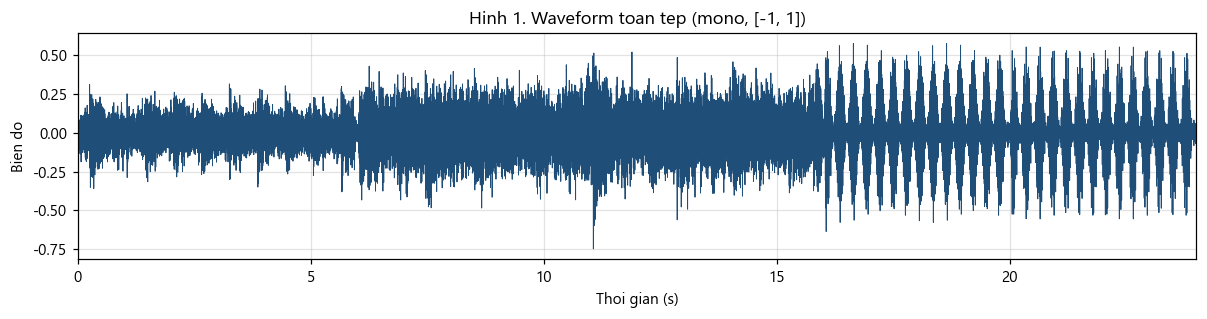

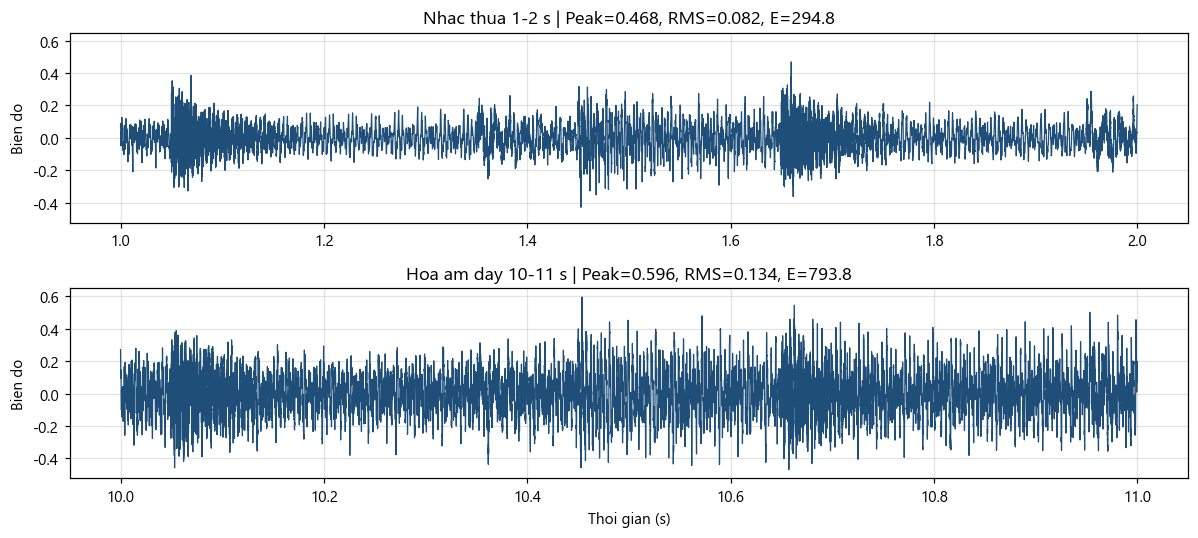

In [4]:
t = np.arange(n) / fs
fig, ax = plt.subplots(figsize=(11, 3.0))
step = max(1, n // 25000)
ax.plot(t[::step], mono[::step], color='#1f4e79', lw=0.6)
ax.set_title('Hinh 1. Waveform toan tep (mono, [-1, 1])')
ax.set_xlabel('Thoi gian (s)')
ax.set_ylabel('Bien do')
ax.set_xlim(0, duration)
fig.tight_layout()
fig.savefig(FIGURES / 'waveform.png')
plt.show()

segments = [('Nhac thua 1-2 s', *T_QUIET), ('Hoa am day 10-11 s', *T_FFT)]
fig, axes = plt.subplots(2, 1, figsize=(11, 5.0), sharey=True)
for ax, (name, t0, t1) in zip(axes, segments):
    sl = mono[int(t0 * fs):int(t1 * fs)]
    tt = np.arange(len(sl)) / fs + t0
    ax.plot(tt, sl, color='#1f4e79', lw=0.8)
    ax.set_title(f'{name} | Peak={np.max(np.abs(sl)):.3f}, RMS={rms(sl):.3f}, E={np.sum(sl**2):.1f}')
    ax.set_ylabel('Bien do')
axes[-1].set_xlabel('Thoi gian (s)')
fig.tight_layout()
fig.savefig(FIGURES / 'waveform_segments.png')
plt.show()


# C. FFT đoạn ổn định 10–11 s

$$f_k = k F_s / N_{\mathrm{FFT}},\qquad \Delta f = F_s/N_{\mathrm{FFT}}$$

True resolution $\approx F_s/L$ ($L$ = độ dài frame thật). Tăng NFFT chỉ nội suy phổ, không tăng độ phân giải vật lý.


L = 44100 mau = 1.000 s
True resolution Fs/L = 1.000 Hz


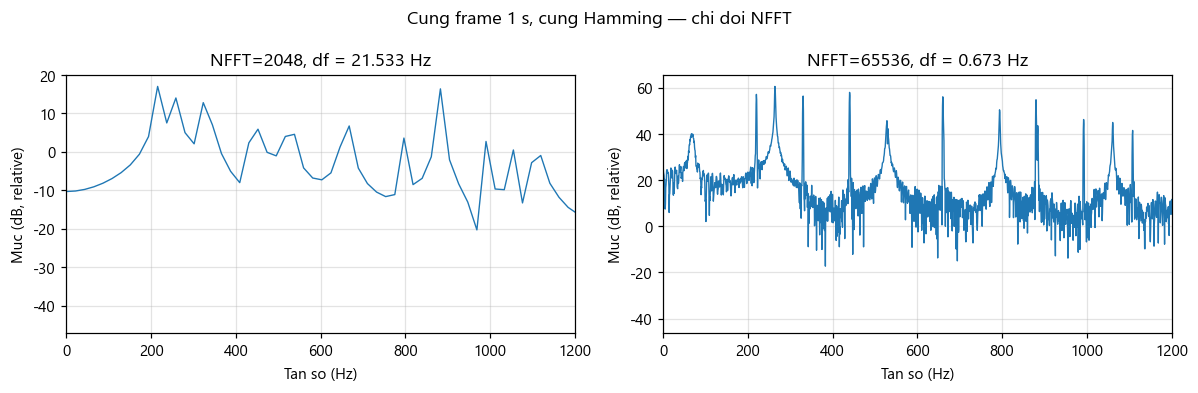

Dinh noi bat (Hz): [ 263.8  440.1  220.   330.4  660.1  880.2  794.  1321.6]


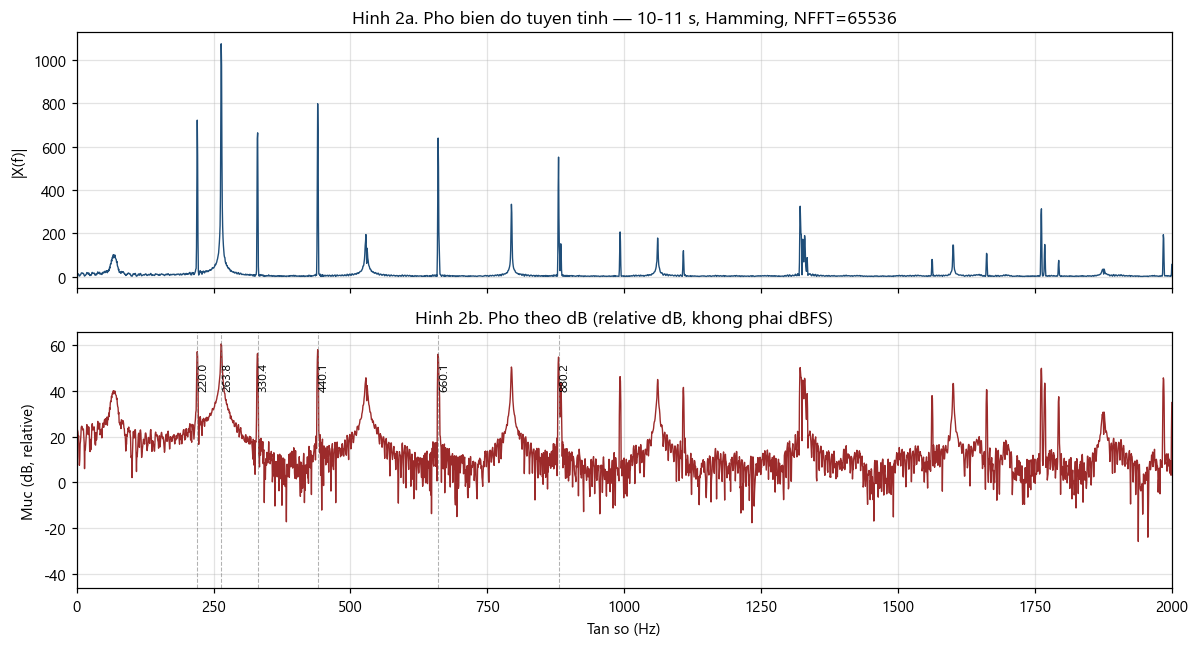

In [5]:
seg = mono[int(T_FFT[0] * fs):int(T_FFT[1] * fs)]
w = np.hamming(len(seg))
print(f'L = {len(seg)} mau = {len(seg)/fs:.3f} s')
print(f'True resolution Fs/L = {fs/len(seg):.3f} Hz')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, nfft in zip(axes, [2048, 65536]):
    X = np.fft.rfft(seg * w, n=nfft)
    f = np.fft.rfftfreq(nfft, 1 / fs)
    ax.plot(f, db(X), lw=0.9)
    ax.set_xlim(0, 1200)
    ax.set_title(f'NFFT={nfft}, df = {fs/nfft:.3f} Hz')
    ax.set_xlabel('Tan so (Hz)')
    ax.set_ylabel('Muc (dB, relative)')
fig.suptitle('Cung frame 1 s, cung Hamming — chi doi NFFT')
fig.tight_layout()
fig.savefig(FIGURES / 'fft_nfft_compare.png')
plt.show()

NFFT = 65536
X = np.fft.rfft(seg * w, n=NFFT)
f = np.fft.rfftfreq(NFFT, 1 / fs)
mag = np.abs(X)
peaks_f = find_peaks_hz(f, mag)
print('Dinh noi bat (Hz):', np.round(peaks_f, 1))

fig, axes = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True)
axes[0].plot(f, mag, color='#1f4e79', lw=0.9)
axes[0].set_xlim(0, 2000)
axes[0].set_ylabel('|X(f)|')
axes[0].set_title('Hinh 2a. Pho bien do tuyen tinh — 10-11 s, Hamming, NFFT=65536')
axes[1].plot(f, db(X), color='#9c2a2a', lw=0.9)
axes[1].set_xlim(0, 2000)
axes[1].set_xlabel('Tan so (Hz)')
axes[1].set_ylabel('Muc (dB, relative)')
axes[1].set_title('Hinh 2b. Pho theo dB (relative dB, khong phai dBFS)')
for pf in peaks_f[:6]:
    axes[1].axvline(pf, color='gray', ls='--', lw=0.7, alpha=0.6)
    axes[1].text(pf, np.max(db(X)) - 8, f'{pf:.1f}', rotation=90, fontsize=8, va='top')
fig.tight_layout()
fig.savefig(FIGURES / 'fft.png')
plt.show()


# D. STFT / spectrogram

Cấu hình chuẩn: frame 25 ms (1102 mẫu), hop 10 ms (441 mẫu), overlap ~60%.

So sánh 10/25/50 ms: **chỉ đổi độ dài frame**, giữ hop và cùng thang màu.


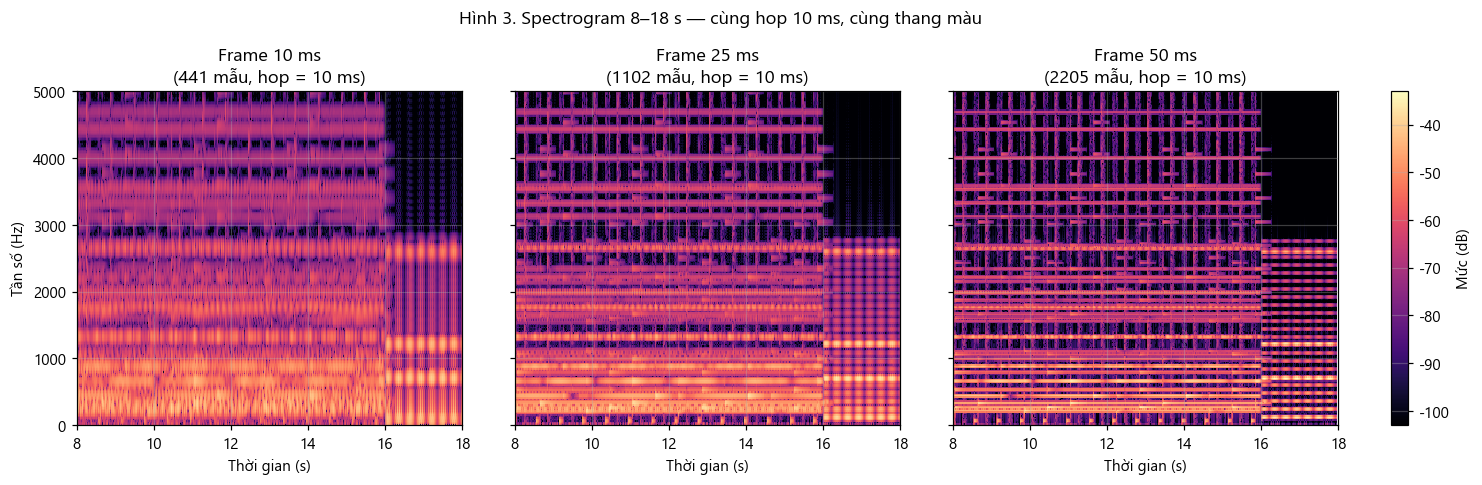

L=1102 mẫu, H=441 mẫu, overlap=661 mẫu (60.0%)


In [6]:
clip = mono[int(T_SPEC[0] * fs):int(T_SPEC[1] * fs)]
hop = int(round(0.010 * fs))
specs = []
for ms in [10, 25, 50]:
    L = int(round(ms / 1000 * fs))
    f_s, t_s, S = signal.spectrogram(
        clip, fs=fs, window='hamming', nperseg=L,
        noverlap=L - hop, nfft=max(2048, L), mode='magnitude')
    specs.append((ms, L, f_s, t_s, db(S)))

vmin = max(s[-1].max() - 70 for s in specs)
vmax = max(s[-1].max() for s in specs)

fig = plt.figure(figsize=(13.6, 4.6))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.045], wspace=0.18, top=0.82, bottom=0.16, left=0.07, right=0.96)
axes = [fig.add_subplot(gs[0, 0])]
axes += [fig.add_subplot(gs[0, i], sharey=axes[0]) for i in range(1, 3)]
cax = fig.add_subplot(gs[0, 3])

for ax, (ms, L, f_s, t_s, S_db) in zip(axes, specs):
    im = ax.pcolormesh(
        t_s + T_SPEC[0], f_s, S_db,
        shading='nearest', cmap='magma', vmin=vmin, vmax=vmax,
    )
    ax.set_ylim(0, 5000)
    ax.set_xlim(T_SPEC[0], T_SPEC[1])
    ax.set_title(f'Frame {ms} ms\n({L} mẫu, hop = 10 ms)')
    ax.set_xlabel('Thời gian (s)')
axes[0].set_ylabel('Tần số (Hz)')
for ax in axes[1:]:
    ax.tick_params(labelleft=False)
fig.colorbar(im, cax=cax, label='Mức (dB)')
fig.suptitle('Hình 3. Spectrogram 8–18 s — cùng hop 10 ms, cùng thang màu', y=0.98)
fig.savefig(FIGURES / 'spectrogram.png', bbox_inches='tight')
plt.show()

L25 = int(round(0.025 * fs))
print(f'L={L25} mẫu, H={hop} mẫu, overlap={L25-hop} mẫu ({100*(L25-hop)/L25:.1f}%)')


# E. Cửa sổ Rectangular vs Hamming

Thí nghiệm công bằng: cùng frame 10–11 s, cùng NFFT=8192. Hamming giảm leakage (side-lobe thấp) nhưng main-lobe rộng hơn.


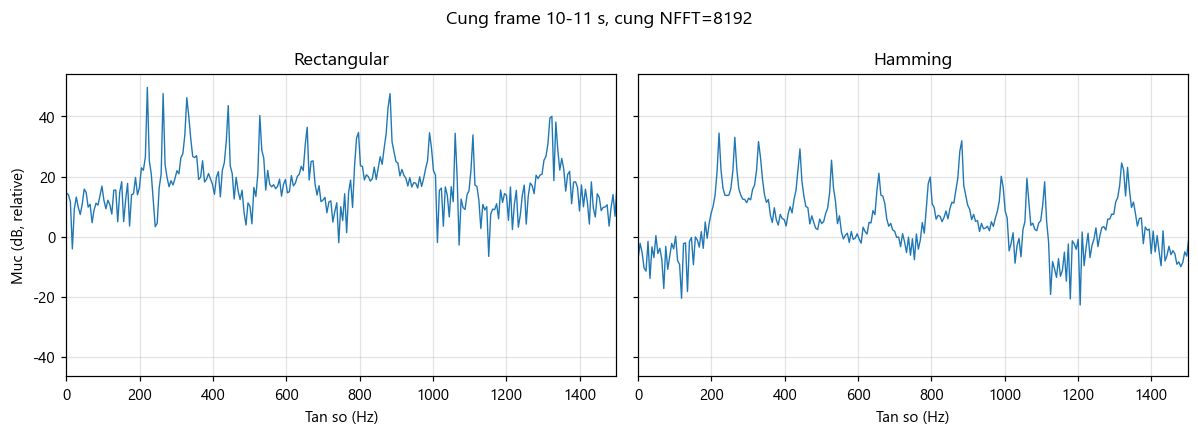

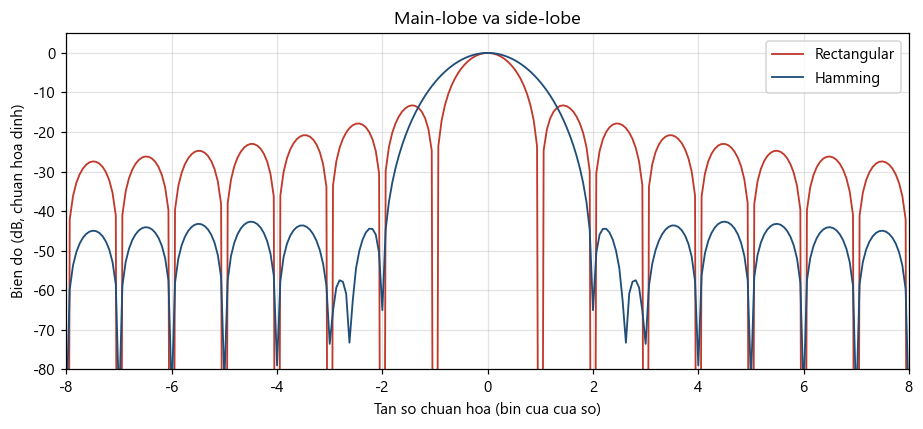

In [7]:
frame = seg.copy()
nfft_w = 8192
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, (name, win) in zip(axes, [
    ('Rectangular', np.ones(len(frame))),
    ('Hamming', np.hamming(len(frame))),
]):
    ax.plot(np.fft.rfftfreq(nfft_w, 1 / fs), db(np.fft.rfft(frame * win, n=nfft_w)), lw=0.9)
    ax.set_xlim(0, 1500)
    ax.set_title(name)
    ax.set_xlabel('Tan so (Hz)')
axes[0].set_ylabel('Muc (dB, relative)')
fig.suptitle('Cung frame 10-11 s, cung NFFT=8192')
fig.tight_layout()
fig.savefig(FIGURES / 'window_compare.png')
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 4.0))
n_win = 512
for name, wfun, c in [('Rectangular', np.ones, '#c0392b'), ('Hamming', np.hamming, '#1f4e79')]:
    W = np.fft.fftshift(np.fft.fft(wfun(n_win), 8192))
    freq = np.fft.fftshift(np.fft.fftfreq(8192)) * n_win
    ax.plot(freq, db(W) - np.max(db(W)), label=name, color=c, lw=1.2)
ax.set_xlim(-8, 8)
ax.set_ylim(-80, 5)
ax.set_xlabel('Tan so chuan hoa (bin cua cua so)')
ax.set_ylabel('Bien do (dB, chuan hoa dinh)')
ax.set_title('Main-lobe va side-lobe')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'window_lobe.png')
plt.show()


# F. Lọc FIR

`firwin` cần truyền `fs`. FIR 201 taps, Hamming: LPF 2 kHz, HPF 2 kHz, BPF 400–2000 Hz.

Group delay $= (L-1)/2 = 100$ mẫu $\approx 2.27$ ms. Khi so phổ trước/sau phải trừ delay.


Group delay = 100 mau = 2.27 ms


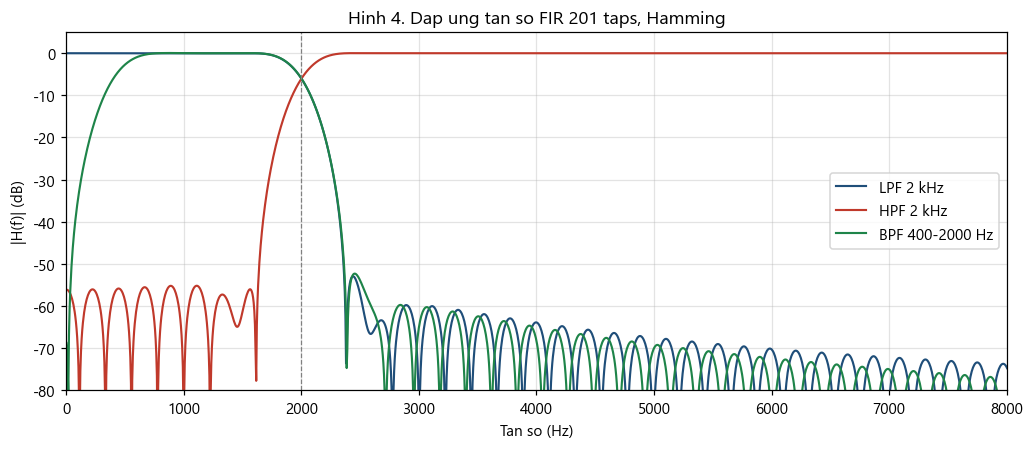

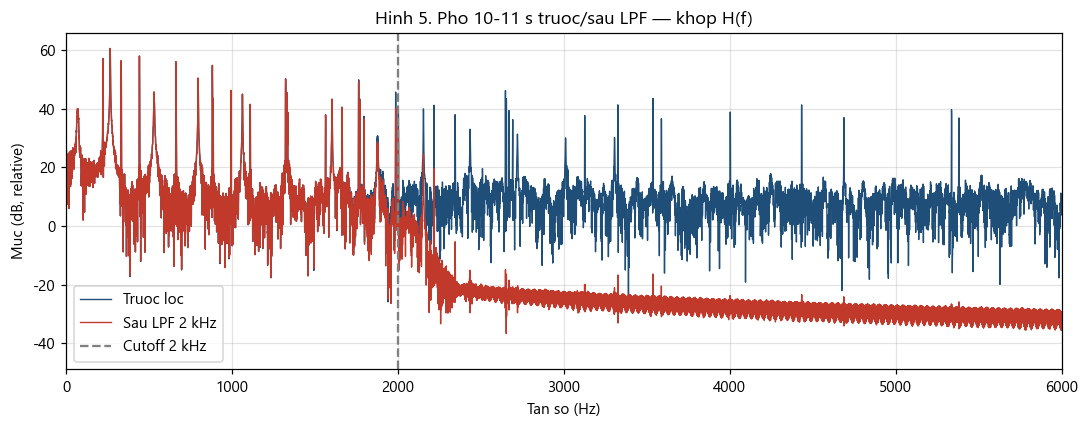

In [8]:
b_lpf = signal.firwin(201, cutoff=2000, fs=fs, window='hamming')
b_hpf = signal.firwin(201, cutoff=2000, fs=fs, window='hamming', pass_zero=False)
b_bpf = signal.firwin(201, cutoff=[400, 2000], fs=fs, window='hamming', pass_zero=False)

y_lpf = signal.lfilter(b_lpf, [1.0], mono)
y_hpf = signal.lfilter(b_hpf, [1.0], mono)
y_bpf = signal.lfilter(b_bpf, [1.0], mono)
delay = (201 - 1) / 2
print(f'Group delay = {delay:.0f} mau = {1000*delay/fs:.2f} ms')

save_wav(AUDIO / 'filtered_lpf_2k.wav', y_lpf)
save_wav(AUDIO / 'filtered_hpf_2k.wav', y_hpf)
save_wav(AUDIO / 'filtered_bpf_400_2000.wav', y_bpf)
save_wav(AUDIO / 'music_lpf_2k.wav', y_lpf)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for b, name, c in [
    (b_lpf, 'LPF 2 kHz', '#1f4e79'),
    (b_hpf, 'HPF 2 kHz', '#c0392b'),
    (b_bpf, 'BPF 400-2000 Hz', '#1e8449'),
]:
    w, H = signal.freqz(b, worN=4096, fs=fs)
    ax.plot(w, db(H), label=name, color=c, lw=1.4)
ax.axvline(2000, color='gray', ls='--', lw=0.8)
ax.set_xlim(0, 8000)
ax.set_ylim(-80, 5)
ax.set_xlabel('Tan so (Hz)')
ax.set_ylabel('|H(f)| (dB)')
ax.set_title('Hinh 4. Dap ung tan so FIR 201 taps, Hamming')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'filter_response.png')
plt.show()

d = int(delay)
i0, i1 = int(T_FFT[0] * fs), int(T_FFT[1] * fs)
Xin = np.fft.rfft(mono[i0:i1] * np.hamming(i1 - i0), n=65536)
Xout = np.fft.rfft(y_lpf[i0 + d:i1 + d] * np.hamming(i1 - i0), n=65536)
ff = np.fft.rfftfreq(65536, 1 / fs)
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.plot(ff, db(Xin), label='Truoc loc', color='#1f4e79', lw=0.9)
ax.plot(ff, db(Xout), label='Sau LPF 2 kHz', color='#c0392b', lw=0.9)
ax.axvline(2000, color='gray', ls='--', label='Cutoff 2 kHz')
ax.set_xlim(0, 6000)
ax.set_xlabel('Tan so (Hz)')
ax.set_ylabel('Muc (dB, relative)')
ax.set_title('Hinh 5. Pho 10-11 s truoc/sau LPF — khop H(f)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'fft_before_after_lpf.png')
plt.show()


# G. Lượng tử hóa, resampling, mã hóa

$$\mathrm{SNR}_Q = 6B + 4.77 - 20\log_{10}(X_{\max}/\sigma_x)$$

Resample bằng `resample_poly` (có anti-alias). Không dùng `x[::k]`.


B= 4  L=   16  d=0.125000  SNR =  10.57 dB
B= 6  L=   64  d=0.031250  SNR =  23.36 dB
B= 8  L=  256  d=0.007812  SNR =  35.59 dB
B=12  L= 4096  d=0.000488  SNR =  59.74 dB
B=16  L=65536  d=0.000031  SNR =  83.83 dB


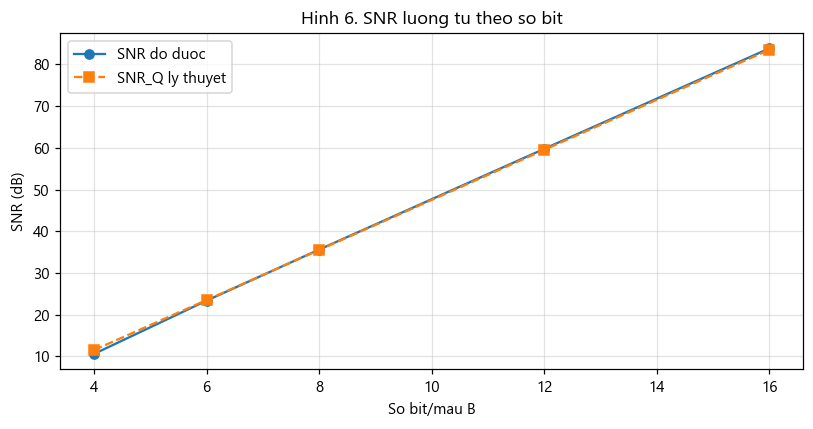

Resample 44100 -> 16000 Hz, 1058400 -> 384000 mau
Resample 44100 -> 8000 Hz, 1058400 -> 192000 mau


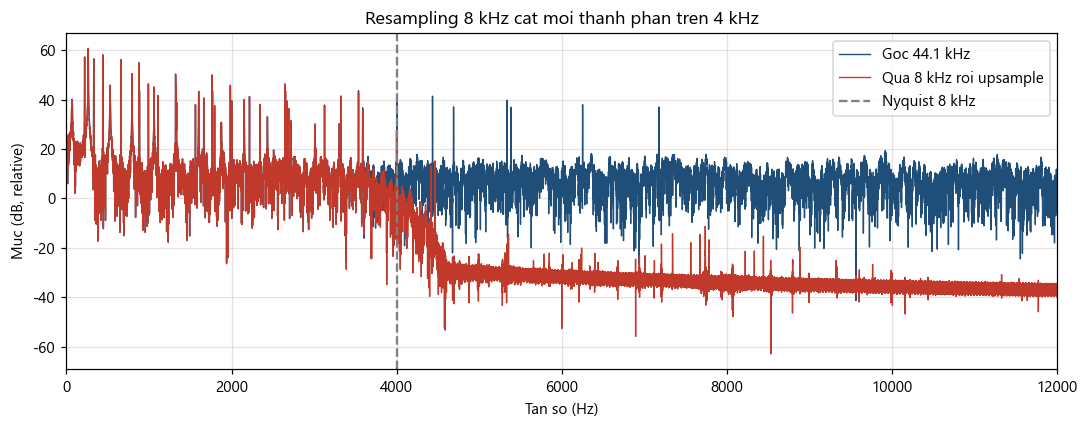

In [9]:
bits = [4, 6, 8, 12, 16]
rows = []
for Bq in bits:
    xq = quantize(mono, Bq)
    val = snr_db(mono, xq)
    rows.append((Bq, val))
    save_wav(AUDIO / f'quantized_{Bq}bit.wav', xq)
    print(f'B={Bq:2d}  L={2**Bq:5d}  d={2/2**Bq:.6f}  SNR = {val:6.2f} dB')

theory = [6 * Bq + 4.77 - 20 * np.log10(1 / rms_mono) for Bq in bits]
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(bits, [r[1] for r in rows], 'o-', label='SNR do duoc')
ax.plot(bits, theory, 's--', label='SNR_Q ly thuyet')
ax.set_xlabel('So bit/mau B')
ax.set_ylabel('SNR (dB)')
ax.set_title('Hinh 6. SNR luong tu theo so bit')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'snr_quantization.png')
plt.show()

for fs_new in (16000, 8000):
    y = resample_audio(mono, fs, fs_new)
    save_wav(AUDIO / f'resampled_{fs_new}.wav', y, fs=fs_new)
    print(f'Resample {fs} -> {fs_new} Hz, {len(mono)} -> {len(y)} mau')

y8_up = resample_audio(resample_audio(mono, fs, 8000), 8000, fs)
fig, ax = plt.subplots(figsize=(10, 4.0))
for sig, lab, c in [
    (mono[i0:i1], 'Goc 44.1 kHz', '#1f4e79'),
    (y8_up[i0:i1], 'Qua 8 kHz roi upsample', '#c0392b'),
]:
    ax.plot(ff, db(np.fft.rfft(sig * np.hamming(len(sig)), n=65536)), label=lab, color=c, lw=0.9)
ax.axvline(4000, color='gray', ls='--', label='Nyquist 8 kHz')
ax.set_xlim(0, 12000)
ax.set_xlabel('Tan so (Hz)')
ax.set_ylabel('Muc (dB, relative)')
ax.set_title('Resampling 8 kHz cat moi thanh phan tren 4 kHz')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'resample_spectrum.png')
plt.show()


R_PCM 16-bit stereo = 1411.2 kbps
R_MP3              = 256.35 kbps
Compression ratio 256 kbps ≈ 5.51 : 1
Compression ratio 128 kbps ≈ 11.03 : 1
Size PCM  ≈ 4.23 MB
Size MP3  ≈ 0.77 MB
Saving    ≈ 81.8 %


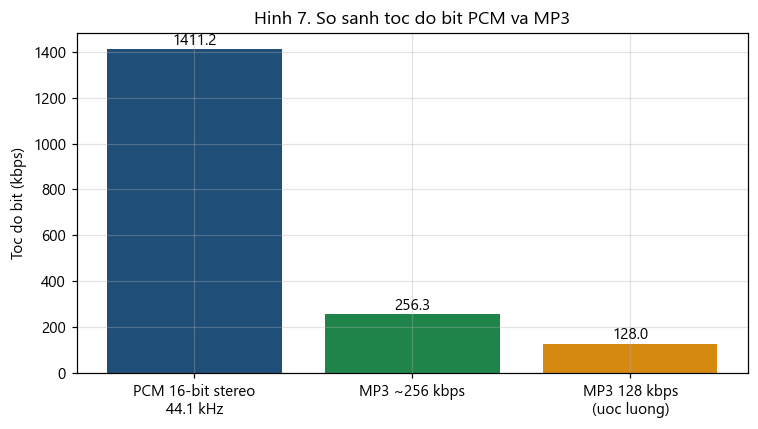

In [10]:
R_pcm = fs * 16 * 2
if mp3_size:
    R_mp3 = mp3_size * 8 / duration
else:
    R_mp3 = 256000
    mp3_size = int(R_mp3 * duration / 8)
cr256 = R_pcm / R_mp3
cr128 = R_pcm / 128000
print('R_PCM 16-bit stereo =', R_pcm / 1000, 'kbps')
print(f'R_MP3              = {R_mp3/1000:.2f} kbps')
print(f'Compression ratio 256 kbps ≈ {cr256:.2f} : 1')
print(f'Compression ratio 128 kbps ≈ {cr128:.2f} : 1')
print(f'Size PCM  ≈ {R_pcm * duration / 8 / 1e6:.2f} MB')
print(f'Size MP3  ≈ {mp3_size / 1e6:.2f} MB')
print(f'Saving    ≈ {(1 - mp3_size / (R_pcm * duration / 8)) * 100:.1f} %')

fig, ax = plt.subplots(figsize=(7.0, 4.0))
labels = ['PCM 16-bit stereo\n44.1 kHz', 'MP3 ~256 kbps', 'MP3 128 kbps\n(uoc luong)']
rates = [R_pcm / 1000, R_mp3 / 1000, 128]
ax.bar(labels, rates, color=['#1f4e79', '#1e8449', '#d68910'])
ax.set_ylabel('Toc do bit (kbps)')
ax.set_title('Hinh 7. So sanh toc do bit PCM va MP3')
for i, v in enumerate(rates):
    ax.text(i, v + 20, f'{v:.1f}', ha='center')
fig.tight_layout()
fig.savefig(FIGURES / 'bitrate_compare.png')
plt.show()
